## CARD: Training Session 7

### Modeling a transient polytropic catalytic fixed bed reactor 

**Implementation**:

- [NumPy](https://numpy.org/) for math and matrix operations
- [casADi](https://web.casadi.org/) to solve the DAE
- [Matplotlib](https://matplotlib.org/) with the module [pyplot](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html) to visualize the results
- time to measure computation wall-clock time

In [ ]:
import time

import casadi as casADi
import matplotlib.pyplot as plt
import numpy as np


Defining values of constant parameters:

In [2]:
R = 8.314                       # [J/Kmol]
Mw_i = np.array([0.002, 0.001]) # [kg/mol]      # 0: A, 1: B
p = 1e5                         # [Pa]
k_0 = 0.8                       # [m^3/(s kg_cat)]
E_A = 10e3                      # [J/mol]
delta_H = -0.5e3                # [J/mol]
nu = np.array([-1, 2])          # [-]
L = 1                           # [m]
D = 20e-3                       # [m]
eps = 0.5                       # [-]
u_in = 1                        # [m/s]
U = 10                          # [W/m^2K]
T_wall = 320                    # [K]
cp_f = 1000                     # [J/kgK]
cp_cat = 700                    # [J/kg/K]
rho_cat = 1000                  # [kg/m^3]
d_cat = 3e-3                    # [m]
D_A = 5e-3                      # [m^2/s]

Using an array as upper bound of the integral to calculate various timesteps:

In [3]:
t_0 = 0         # [s]
t_steps = 101   # [-]
t_end = 500     # [s]
t_i = np.linspace(t_0, t_end, t_steps)

Setting the values and vector for the axial discretization:

In [4]:
n_axial = 200
delta_z = 1 / n_axial
z_c = np.linspace(0 + delta_z / 2, 1 - delta_z / 2, n_axial)

Now setting the initial and boundary conditions:

In [5]:
w_i_0 = np.array([1, 0])    # [-]   # 0:A, 1:B
T_0 = 300                   # [K]
w_i_in = np.array([1, 0])   # [-]   # 0:A, 1:B
T_in = 300                  # [K]

Defining necessary differential and algebraic symbolic variables:

In [6]:
w_i = casADi.SX.sym("w_i", (n_axial, 2))    # differential  # [-]   # A, B
T = casADi.SX.sym("T", n_axial)             # differential  # [K]
u = casADi.SX.sym("u", n_axial)             # algebraic     # [m/s]

Defining all implicit variables:

In [7]:
def f_Mw(w_i):
    unity = casADi.DM.ones(len(Mw_i))
    Mw = 1 / (casADi.dot(w_i / casADi.SX((Mw_i)), unity))
    return Mw


def f_cf(T):
    cf = p / (R * T)
    return cf


def f_rho(w_i, T):
    rho = f_cf(T) * f_Mw(w_i)
    return rho


def f_ci(w_i, T):
    c_i = w_i * f_Mw(w_i) / Mw_i * f_cf(T)
    return c_i


def f_r(w_i, T):
    r = f_ci(w_i, T)[0] * k_0 * casADi.exp(-E_A / (R * T))
    return r


def f_rho_cp_eff(w_i, T):
    rho_cp_eff = eps * f_rho(w_i, T) * cp_f + (1 - eps) * rho_cat * cp_cat
    return rho_cp_eff


def f_thiele(w_i, T):
    thiele = d_cat / 2 * ((f_r(w_i, T) * rho_cat) / (D_A * f_ci(w_i, T)[0])) ** 0.5
    return thiele


def f_eta(w_i, T):
    eta = (
        3
        / f_thiele(w_i, T)
        * (1 / casADi.tanh(f_thiele(w_i, T)) - 1 / f_thiele(w_i, T))
    )
    return eta

Define the algebraic equation for the mass conservation:

In [8]:
ae = casADi.SX.sym("ae", n_axial)
for z in range(n_axial):
    ae[z] = u[z] - u_in * f_rho(w_i_in, T_in) / f_rho(w_i[z, :].T, T[z])

Define the differential equation for species conservation without the boundary:

In [9]:
ode_wi = casADi.SX.sym("ode_wi", (n_axial, 2))
for comp in range(len(nu)):
    for z in range(1, n_axial):
        ode_wi[z, comp] = (
            -(w_i[z, comp] - w_i[z - 1, comp]) * u[z] / (L * delta_z * eps) + 
            Mw_i[comp] / (f_rho(w_i[z, :].T, T[z]) * eps) * (1 - eps) 
            * rho_cat * nu[comp] * f_eta(w_i[z, :].T, T[z]) * f_r(w_i[z, :].T, T[z])
        )

Define the differential equation at the boundary:

In [10]:
z = 0
for comp in range(len(nu)):
    ode_wi[z, comp] = (
        -(w_i[z, comp] - w_i_in[comp]) * u[z] / (L * delta_z * eps) + 
        Mw_i[comp] / (f_rho(w_i[z, :].T, T[z]) * eps) * (1 - eps) 
        * rho_cat * nu[comp] * f_eta(w_i[z, :].T, T[z]) * f_r(w_i[z, :].T, T[z])
    )

Define the differential equation for energy conservation without the boundary:

In [11]:
ode_T = casADi.SX.sym("ode_T", n_axial)
for z in range(1, n_axial):
    ode_T[z] = (
        1
        / (f_rho_cp_eff(w_i[z, :].T, T[z]))
        * (
            -(T[z] - T[z - 1])
            * (u[z] * f_rho(w_i[z, :].T, T[z]) * cp_f)
            / (L * delta_z)
            - 4 * U / D * (T[z] - T_wall)
            + f_eta(w_i[z, :].T, T[z])
            * f_r(w_i[z, :].T, T[z])
            * (-delta_H)
            * (1 - eps)
            * rho_cat
        )
    )

Define the differential equation at the boundary:

In [12]:
z = 0
ode_T[z] = (
    1
    / (f_rho_cp_eff(w_i[z, :].T, T[z]))
    * (
        -(T[z] - T_in) * (u[z] * f_rho(w_i[z, :].T, T[z]) * cp_f) / (L * delta_z)
        - 4 * U / D * (T[z] - T_wall)
        + f_eta(w_i[z, :].T, T[z])
        * f_r(w_i[z, :].T, T[z])
        * (-delta_H)
        * (1 - eps)
        * rho_cat
    )
)

Reshape 2D arrays into 1D vector needed for DAE solver:

In [13]:

w_i_reshaped = casADi.reshape(w_i, n_axial * len(nu), 1)
ode_wi_reshaped = casADi.reshape(ode_wi, n_axial * len(nu), 1)
x = casADi.vertcat(w_i_reshaped, T)
ode = casADi.vertcat(ode_wi_reshaped, ode_T)

Next a casADi specific dictionary is created with the following entries:

In [14]:
dae = {}
dae["x"] = x
dae["z"] = u
dae["ode"] = ode
dae["alg"] = ae

Then define and call the integrator to solve the DAE:

In [15]:
options = {"abstol": 1e-13, "reltol": 1e-13}
I = casADi.integrator("I", "idas", dae, t_0, t_i, options)
x_0 = np.zeros(n_axial * (len(nu) + 1))
x_0[0:n_axial] = w_i_0[0]
x_0[n_axial : 2 * n_axial] = w_i_0[1]
x_0[2 * n_axial :] = T_0
res_dic = I(x0=x_0)

Results need to be reshaped like this:

In [16]:
res_x = res_dic["xf"].full()
w_i_res = np.empty(shape=(n_axial, t_steps, len(nu)))
T_res = np.empty(shape=(n_axial, t_steps))
for t in range(t_steps):
    T_res[:, t] = res_x[len(nu) * n_axial :, t]
    for comp in range(len(nu)):
        w_i_res[:, t, comp] = res_x[comp * n_axial : n_axial * (comp + 1), t]
u_res = res_dic["zf"].full()

Check the mass conservation of the solution:

In [17]:
MassFluxDev = np.empty(shape=(n_axial, t_steps))
mdot_0 = float(u_in * f_rho(w_i_in, T_in))
for t in range(t_steps):
    for z in range(n_axial):
        MassFluxDev[z, t] = (
            abs(
                mdot_0
                - (u_res[z, t] * float(f_rho(w_i_res[z, t, :].T, T_res[z, t])))
            )
            / mdot_0
            * 100
        )
print(f"Maximal mass flux deviation: {np.max(MassFluxDev)}")

Maximal mass flux deviation: 1.3984047253501333e-11


Calculate eta for post processing and check time needed to calculate:

In [18]:
eta = np.empty(shape=(n_axial, t_steps))
# Define eta as casADi function to speed up postprocessing calculation
w_eta = casADi.SX.sym("w_eta", 2)   # [mol/m^3]  # A, B 
T_eta = casADi.SX.sym("T_eta")      # [K]
f_eta_casADI = casADi.Function("f_eat_casADi", [w_eta, T_eta], [f_eta(w_eta, T_eta)])
start = time.time()
for t in range(t_steps):
    for z in range(n_axial):
        eta[z, t] = f_eta_casADI(w_i_res[z, t, :], T_res[z, t])
end = time.time()
print(end - start)

0.40350937843322754


Plot the results:

Text(0.5, 0, '$z/L$')

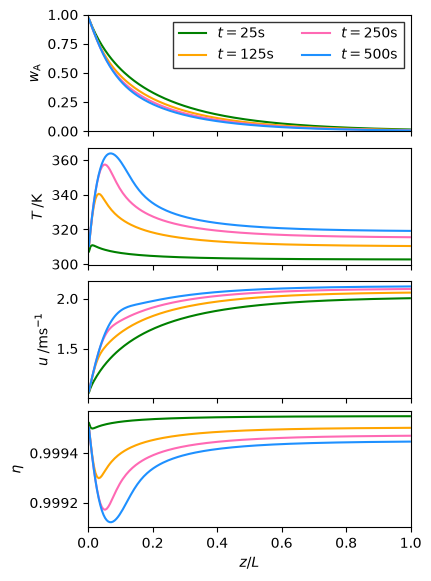

In [19]:
# Create figure and axes of plot
fig, axs = plt.subplots(4, 1, figsize=(4.2, 5.7), constrained_layout=True, sharex=True)

# Plot values
axs[0].plot(z_c, w_i_res[:, 5, 0], color="green", label=r"$t= 25 \mathregular{s}$")
axs[0].plot(z_c, w_i_res[:, 25, 0], color="orange", label=r"$t= 125 \mathregular{s}$")
axs[0].plot(z_c, w_i_res[:, 50, 0], color="hotpink", label=r"$t= 250 \mathregular{s}$")
axs[0].plot(z_c, w_i_res[:, 100, 0], color="dodgerblue", label=r"$t= 500 \mathregular{s}$")

axs[1].plot(z_c, T_res[:, 5], color="green")
axs[1].plot(z_c, T_res[:, 25], color="orange")
axs[1].plot(z_c, T_res[:, 50], color="hotpink")
axs[1].plot(z_c, T_res[:, 100], color="dodgerblue")

axs[2].plot(z_c, u_res[:, 5], color="green")
axs[2].plot(z_c, u_res[:, 25], color="orange")
axs[2].plot(z_c, u_res[:, 50], color="hotpink")
axs[2].plot(z_c, u_res[:, 100], color="dodgerblue")

axs[3].plot(z_c, eta[:, 5], color="green")
axs[3].plot(z_c, eta[:, 25], color="orange")
axs[3].plot(z_c, eta[:, 50], color="hotpink")
axs[3].plot(z_c, eta[:, 100], color="dodgerblue")

# Set axes parameters
axs[0].set_xlim(0, 1)
axs[0].set_ylim(0, 1)
axs[0].set_ylabel("$w_{\\mathregular{A}}$")
axs[0].legend(fancybox=False, loc="best", ncol=2, edgecolor="black")

axs[1].set_ylabel("$T \\; \\mathregular{/K}$")

axs[2].set_ylabel("$u \\; \\mathregular{/ms^{-1}}$")

axs[3].set_ylabel("$\\eta$")
axs[3].set_xlabel("$z/L$")